# Logistic Regression

- There are 2 ways to explain logistic regression:
  1. Geometric way
  2. Probabilistic way

- So, first we will learn using the probabilistic way, and then we will learn using the geometric way. That way, we will have a better understanding of logistic regression.

# Pre-requisites to apply logistic regression

- The data should be linearly classifiable. This means that we should be able to draw a straight line (or a hyperplane in higher dimensions) that separates the classes in the feature space.

    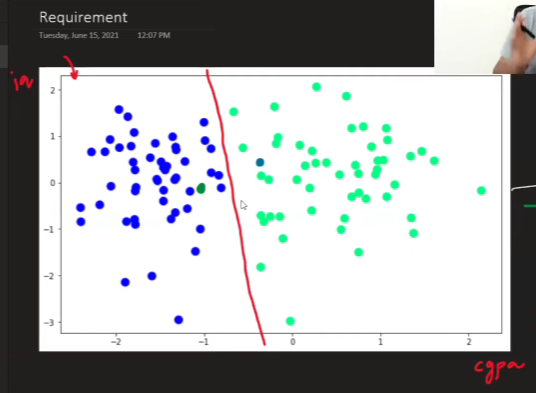

- So, let's start our journey of learning logistic regression using the probabilistic way.

- We will discuss 2 different approaches to understand logistic regression:

  1. **Perceptron Trick**
    - The benefit of using this approach is that it gives the solution  very easily but it doesn't give the best possible solution

  2. The best possible solution is found using some other approach, but to understand that approach, we need to understand the perceptron trick first. So, we will start with the perceptron trick.

# Perceptron Trick

- The dataset have 2 features (cgpa (x1) and iq (x2)) and the green points are students who got placed and the blue points are students who didn't get placed.

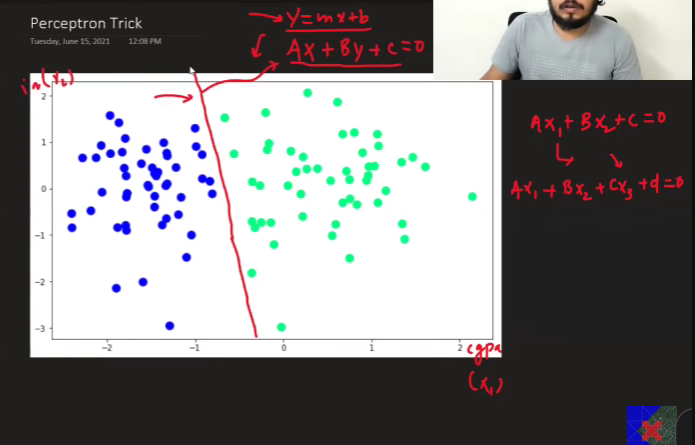

- As you can see, the data is linearly classifiable. So, we can draw a straight line that separates the green points from the blue points.

- In Logistic Regression we don't use the equation of a straight line as $y = mx + b$, we rather use the below equation of a straight line.

- The equation of a straight line in 2D is given by:

    $$Ax_1 + Bx_2 + C = 0$$

    where $A$ and $B$ are the weights and $C$ is the bias.

    **(SO WE HAVE TO FIND THE VALUES OF A, B AND C)**

### How does the perceptron trick find the values of A, B and C?

1. Start with any random values of A, B and C. For example, let's say we start with A = 1, B = 1 and C = 0 {it means we are starting with a random line}

    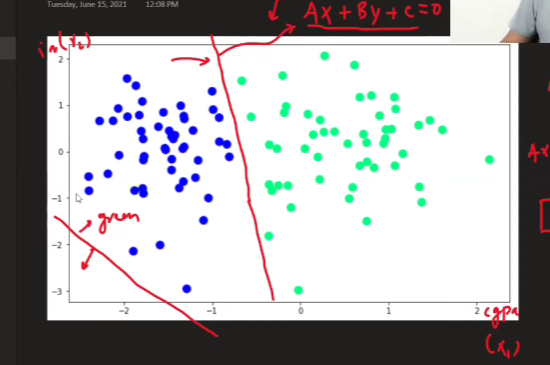

    - So, for the initial line we are telling that everything towards the right of the line is classified as green points (sbka placement ho jayega) and everything towards the left of the line is classified as blue points. Which is teribly wrong

2. Then run a loop, and in each iteration we will go to the data points and check if they are classified correctly or not. If they are classified correctly, then we will do nothing. But if they are classified incorrectly, then we will update the values of A, B and C such that the line moves towards the misclassified point.

    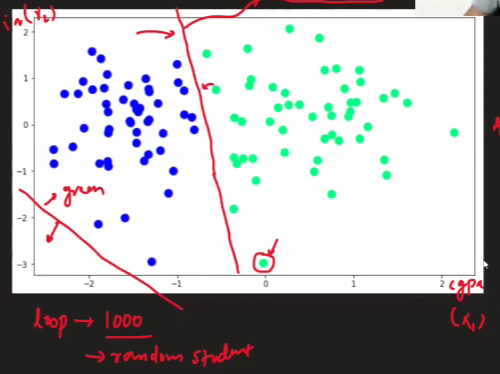

    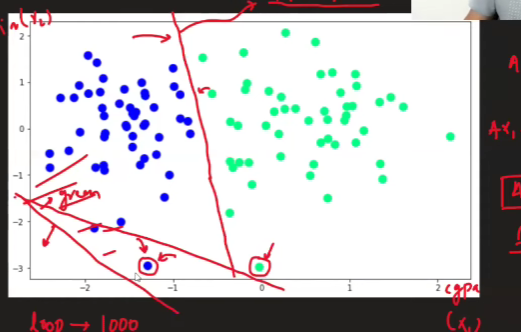

    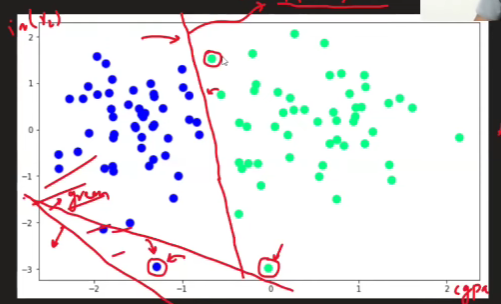

    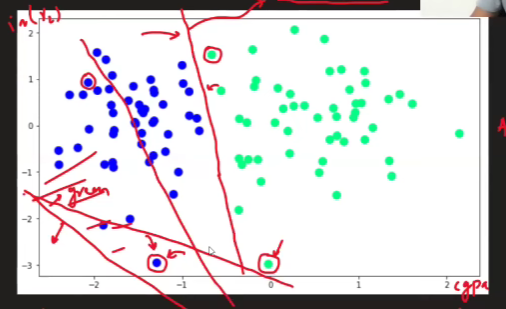

    -  see we went to the green point , so its classification is correct, so we will do nothing. Then we went to the blue point, so its classification is incorrect, so we will update the values of A, B and C such that the line moves towards the blue point.


### How many times do we have to run the loop?

- Two ways people use:

    1. Set number of epochs to 1000 it will mostly get the best possible line, but it is not guaranteed. If not then we can increase the number of epochs to 10000 and it will get the best possible line, but again it is not guaranteed. So, we can keep increasing the number of epochs until we get the best possible line.

    2. Run the loop till it converges. It means there is no more misclassified point or a very small number of misclassified points.

## How these transformations of A, B and C are done?

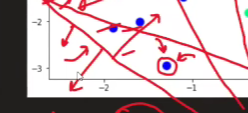

- Earlier we told that the region to the right of the line is classified as green region and to the left of the line is classified as blue region. So,hume ye kese pata chala

- Before we see how the transformations of A, B and C are done, let's see ki hume kese pata chalega ki konsa region positive (green) hai aur konsa region negative (blue) hai?

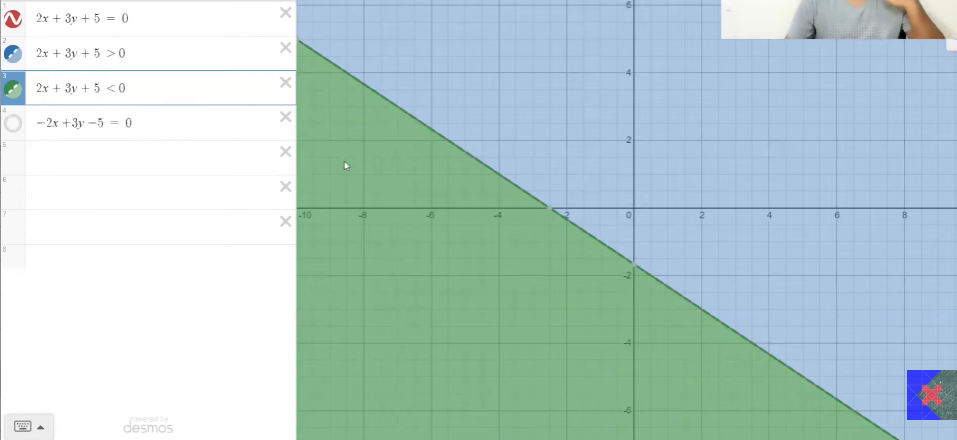

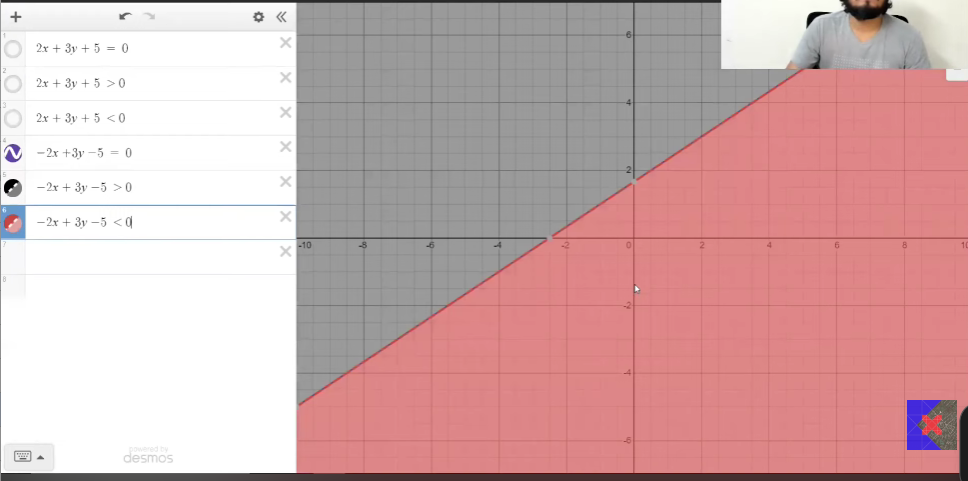

- So we use inequality to determine which region is classified as green and which region is classified as blue. We will use the equation of the line to determine this.

### How to transform the line (update the values of A, B and C)?

- All the parameter have different impact on the line

    - If we vary $C$, it shifts the line parallel to itself.

    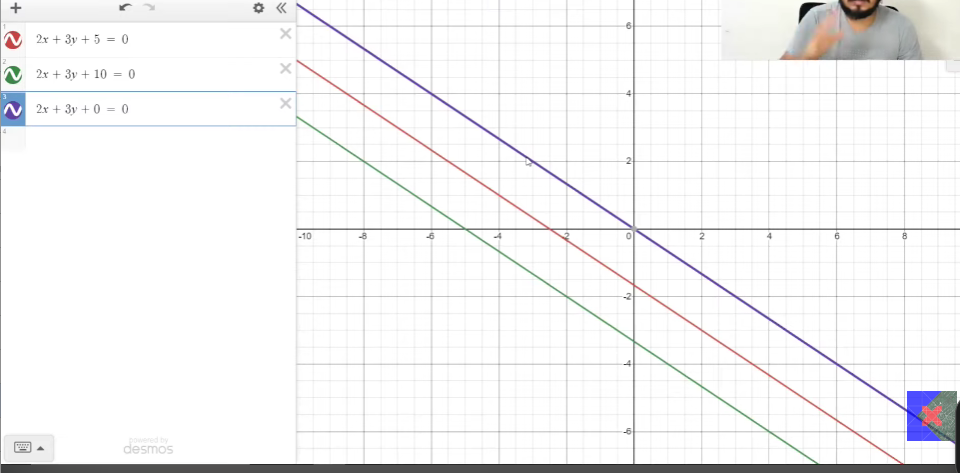

    - If we vary $A$ and $B$, it changes the slope of the line about the fearures respectively.

    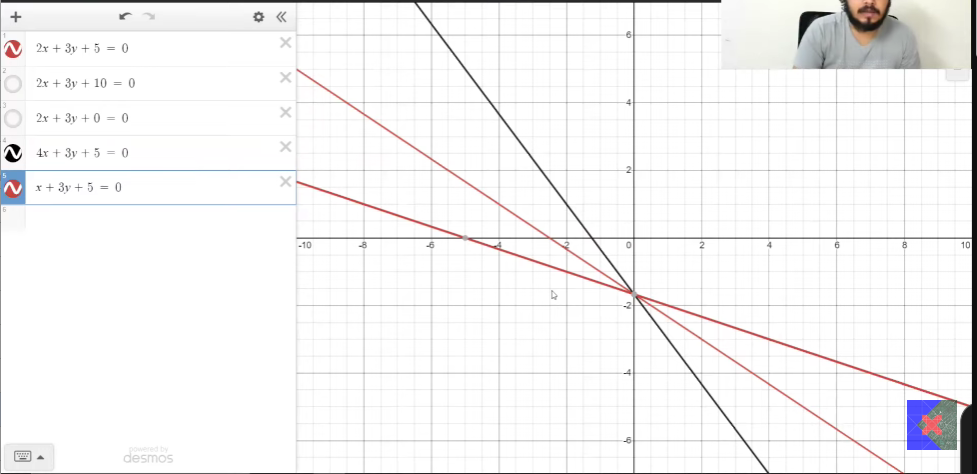

    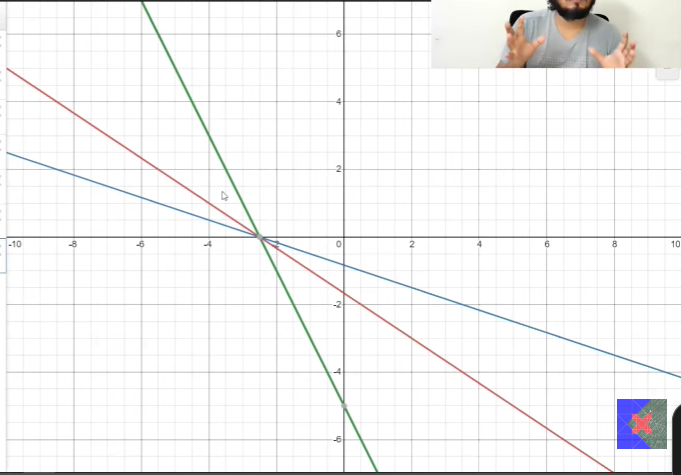

- To understand the transformation, lets take a small dummy dataset with 4 data points. 2 green points and 2 blue points. and out of them 1 green point and 1 blue point are misclassified.

    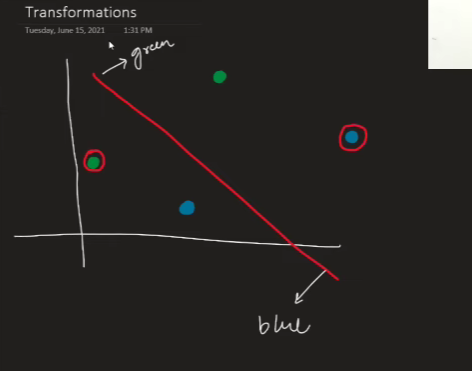

- Suppose the equation of line is $2x_1 + 3x_2 + 5 = 0$ and the misclassified blue point is (4,5), so to transform A,B,C we will do the following:

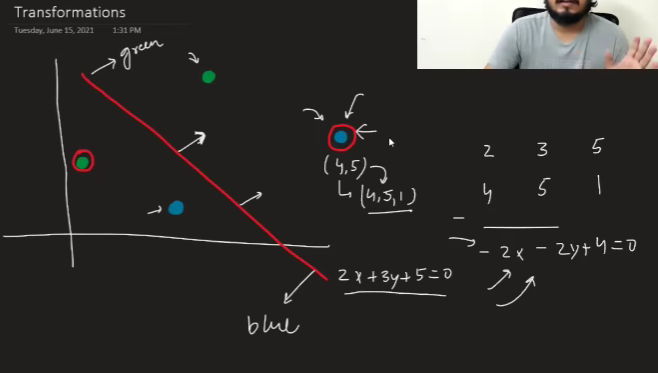

   1. To the point coordinate (4,5) do (4,5,1) {we are adding 1 to the point coordinate because we want to update the bias term C as well}

   2.  Now subtract the point coordinate from the line equation, so we will do (2,3,5) - (4,5,1) = (-2,-2,4)

    - So the new values of A, B and C will be -2, -2 and 4 respectively. So the new line equation will be:
    $$-2x_1 - 2x_2 + 4 = 0$$

    - So the line have transformed in such a way that it will take the misclassified point towards the negative region (blue region)

- Now we will do the same thing for the misclassified green point (1,3)

    1. To the point coordinate (1,3) do (1,3,1)

    2. Now add the point coordinate to the line equation, so we will do (2,3,5) + (1,3,1) = (3,6,6)

    - So the new values of A, B and C will be 3, 6 and 6 respectively. So the new line equation will be:
    $$3x_1 + 6x_2 + 6 = 0$$

    - So the line have transformed in such a way that it will take the misclassified point towards the positive region (green region)

### <span style="color:orange">So, agar humara negative point, Positive region mei hai then we SUBTRACT, and id humara positive point, Negative region mei hai then we ADD</span> 

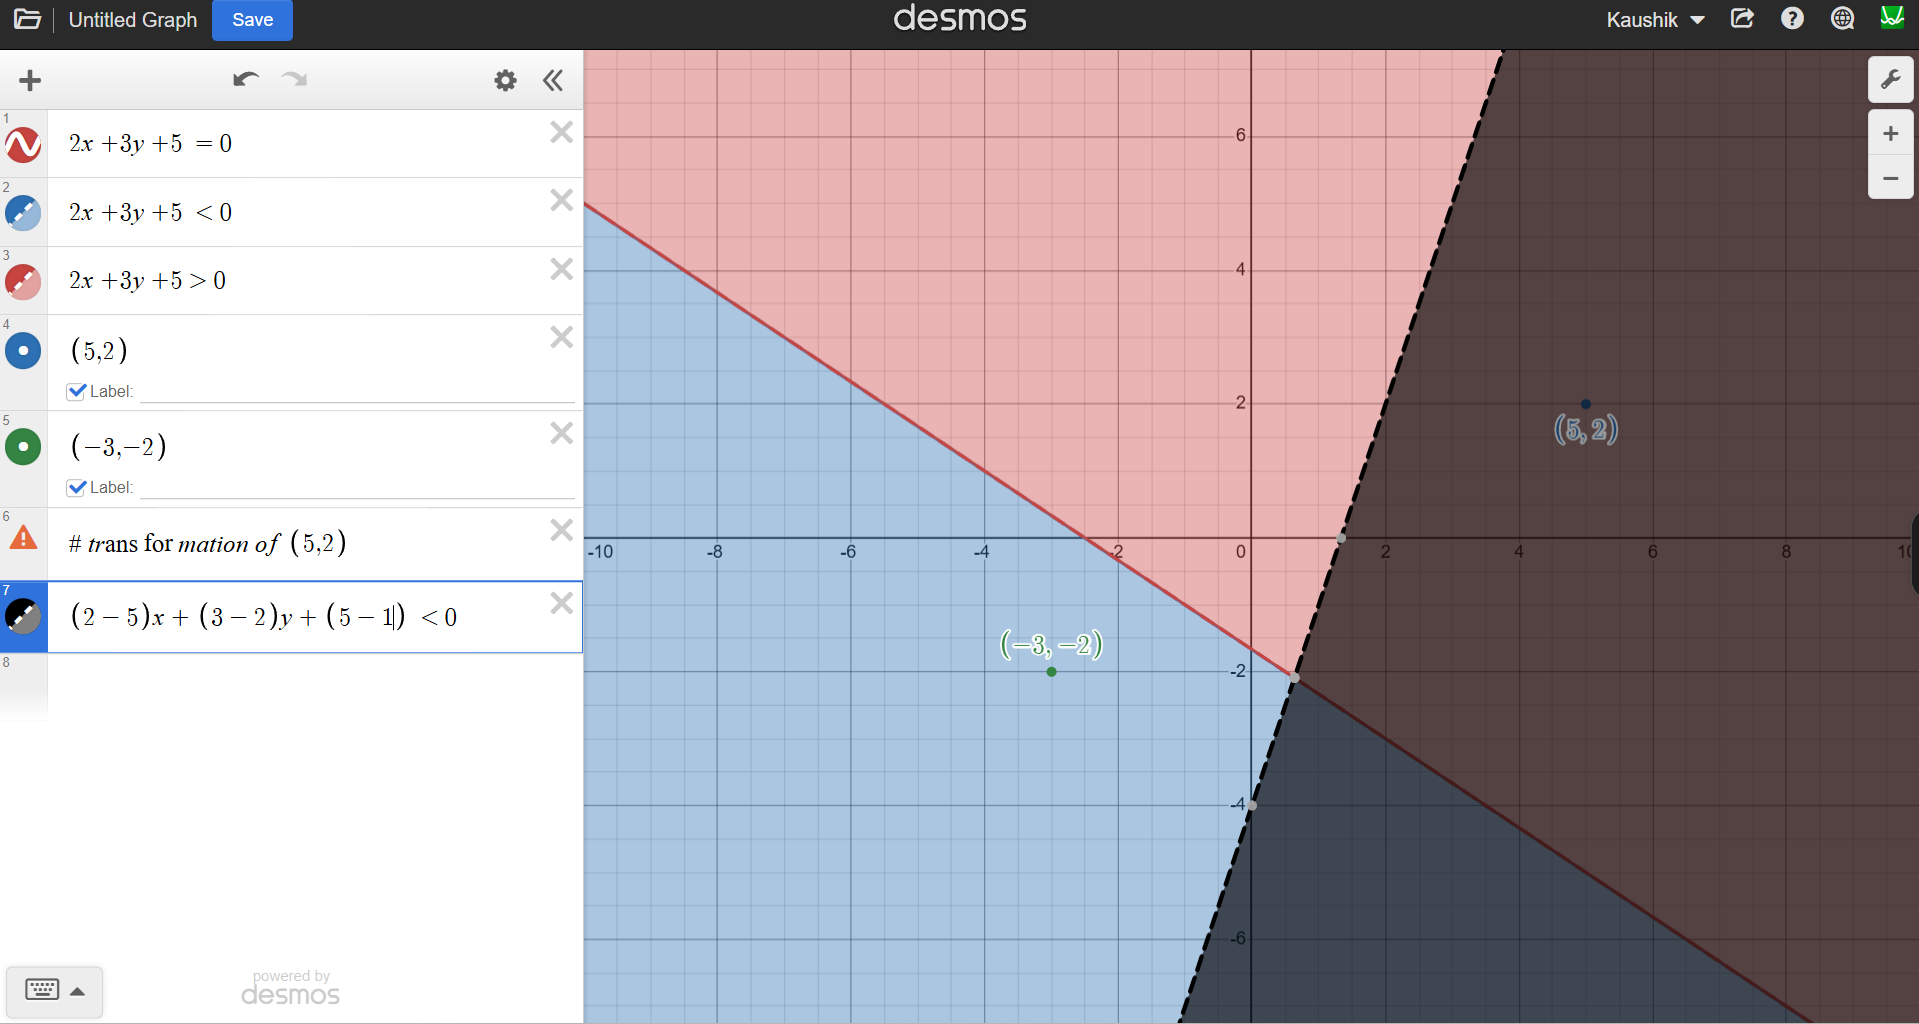

- As you can see, for the line $2x + 3y + 5 = 0$, the point (5,2) is in Positive region but it is a negative point, so we will do (2,3,5) - (5,2,1) = (-3,1,4) , and now you can see the point (5,2) is in negative region for the new line equation -3x + 1y + 4 = 0 (black shaded)

- But in ML we never do big transformation, so we use **learning rate** to do small transformation. So, we will multiply the point coordinate with a small learning rate (for example 0.01) before adding or subtracting it from the line equation.

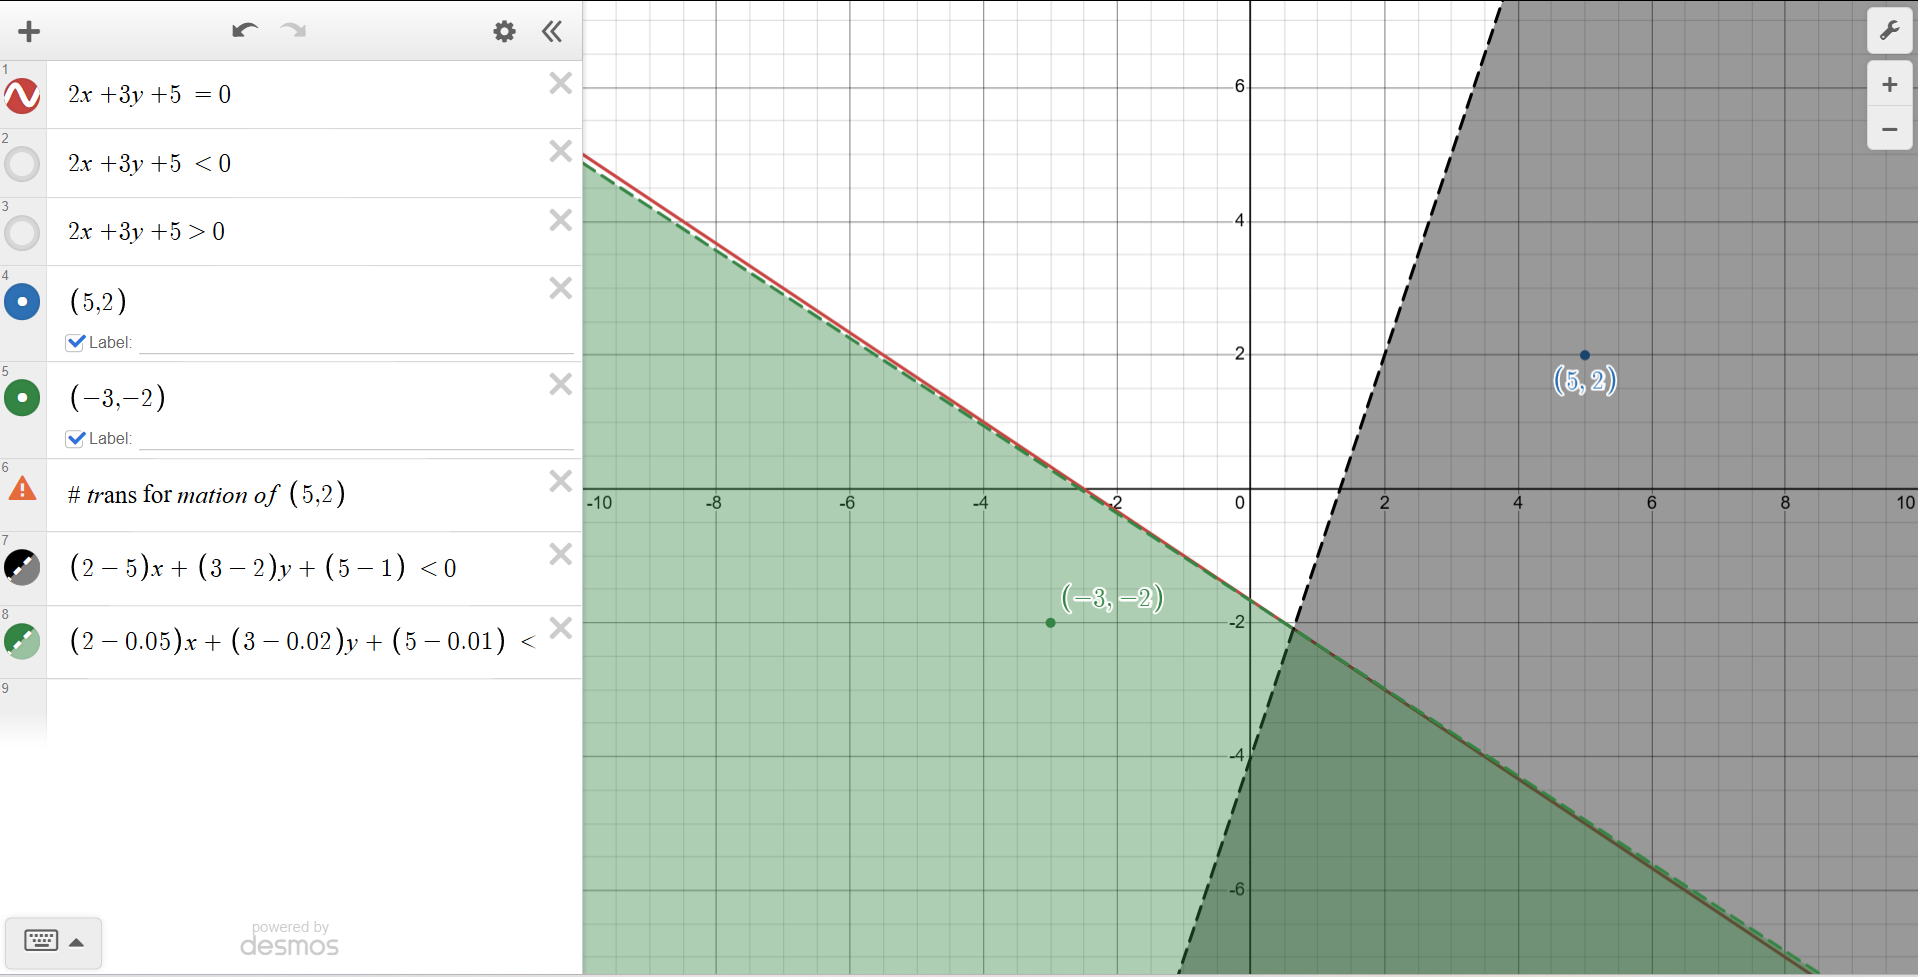

- As you can see, on using the learning rate the point is still misclassified but it is not as much misclassified as before, so we will keep doing this process until we get the best possible line that separates the green points from the blue points.

> Learning rate does not guarantee immediate correction — it ensures gradual and stable learning over iterations.



# Writing the algorithm for the perceptron trick

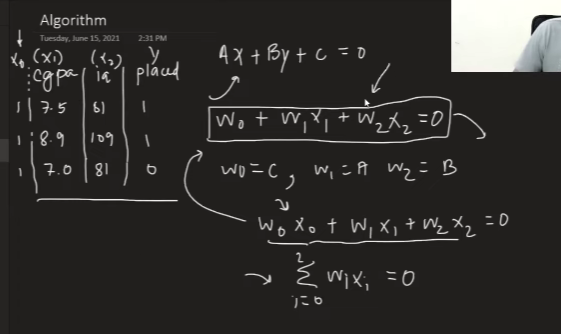

- General line equation is given by (for n-features):


    ### $$\sum_{i=0}^{n} w_i x_i = 0$$

- After we do the LR and find the values of coefficients, we can use the line equation to make predictions. Put the feature values into the equation. If the value of the line equation is greater than 0, then we will classify it as green point (positive class), and if the value of the line equation is less than 0, then we will classify it as blue point (negative class).

$$ [W_0, W_1, ..., W_n] [x_0, x_1, ..., x_n]^T >=< 0 $$

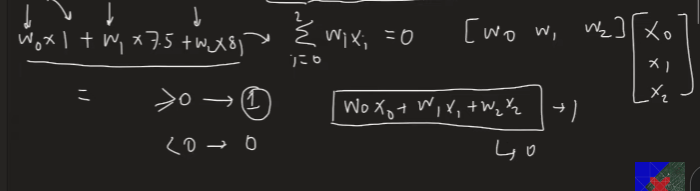

- **The algorithm for the perceptron trick is as follows:**

    1. Initialize the weights and bias to random values.

    2. For each epoch:
        - randomly select a data point from the training set
        - Calculate the output using the line equation (guessed line)
        - If the output is greater than 0 and the true label is less than 0 (misclassified blue point), then update the weights and bias by subtracting the feature values from the line equation.
        - If the output is less than 0 and the true label is greater than 0 (misclassified green point), then update the weights and bias by adding the feature values to the line equation.

        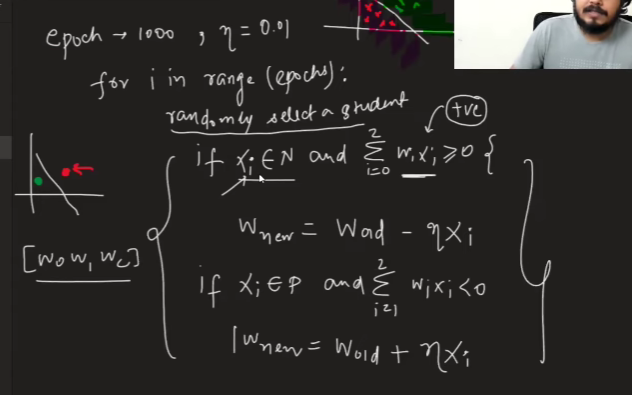

# Simplified Algorithm for the Perceptron Trick

- Instead of using 2 if condition, we can use the following simplified algorithm:

    1. Initialize the weights and bias to random values.

    2. For each epoch:
        - randomly select a data point from the training set
        - Calculate the output using the line equation (guessed line)
        - Update the weights and bias using the following formula:

$$
W_{new} = W_{old} + learning\_rate * (y - y\_hat) * x
$$

- where $y$ is the true label, $y\_hat$ is the predicted label, and $x$ is the feature vector of the data point. W_old is the old weights and bias vector, and W_new is the new weights and bias vector after the update.

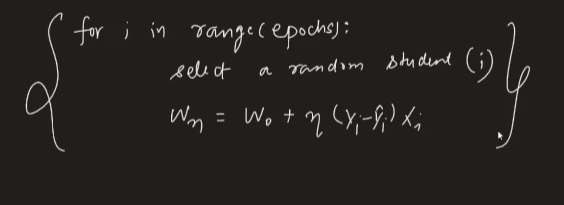

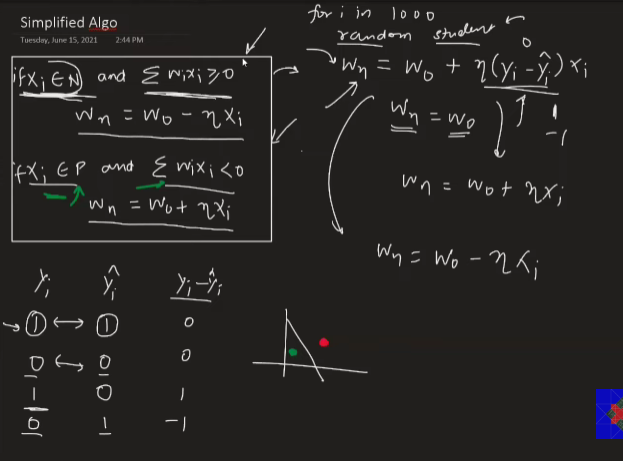 


In [ ]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [2]:
import matplotlib.pyplot as plt

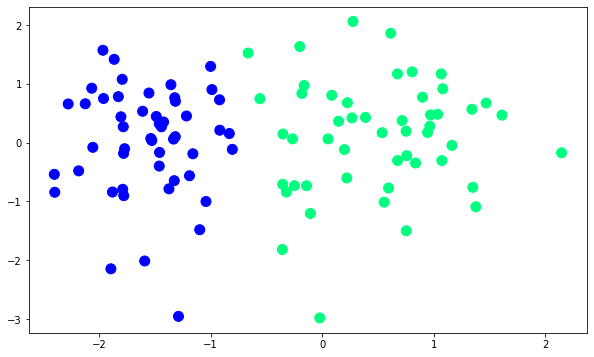

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [10]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]
        

In [11]:
def step(z):
    return 1 if z>0 else 0

In [12]:
intercept_,coef_ = perceptron(X,y)

In [13]:
print(coef_)
print(intercept_)

[1.44152475 0.10464821]
0.9


In [14]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [15]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

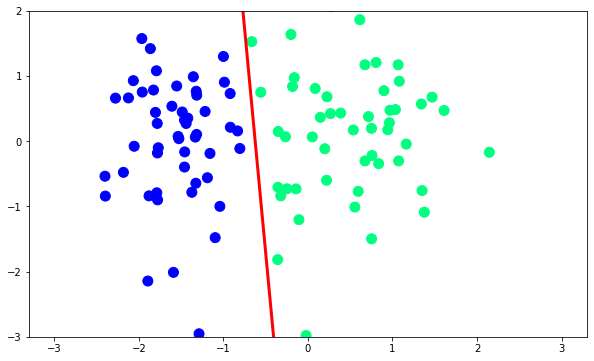

In [16]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [57]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [58]:
m,b = perceptron(X,y)

In [59]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

<IPython.core.display.Javascript object>


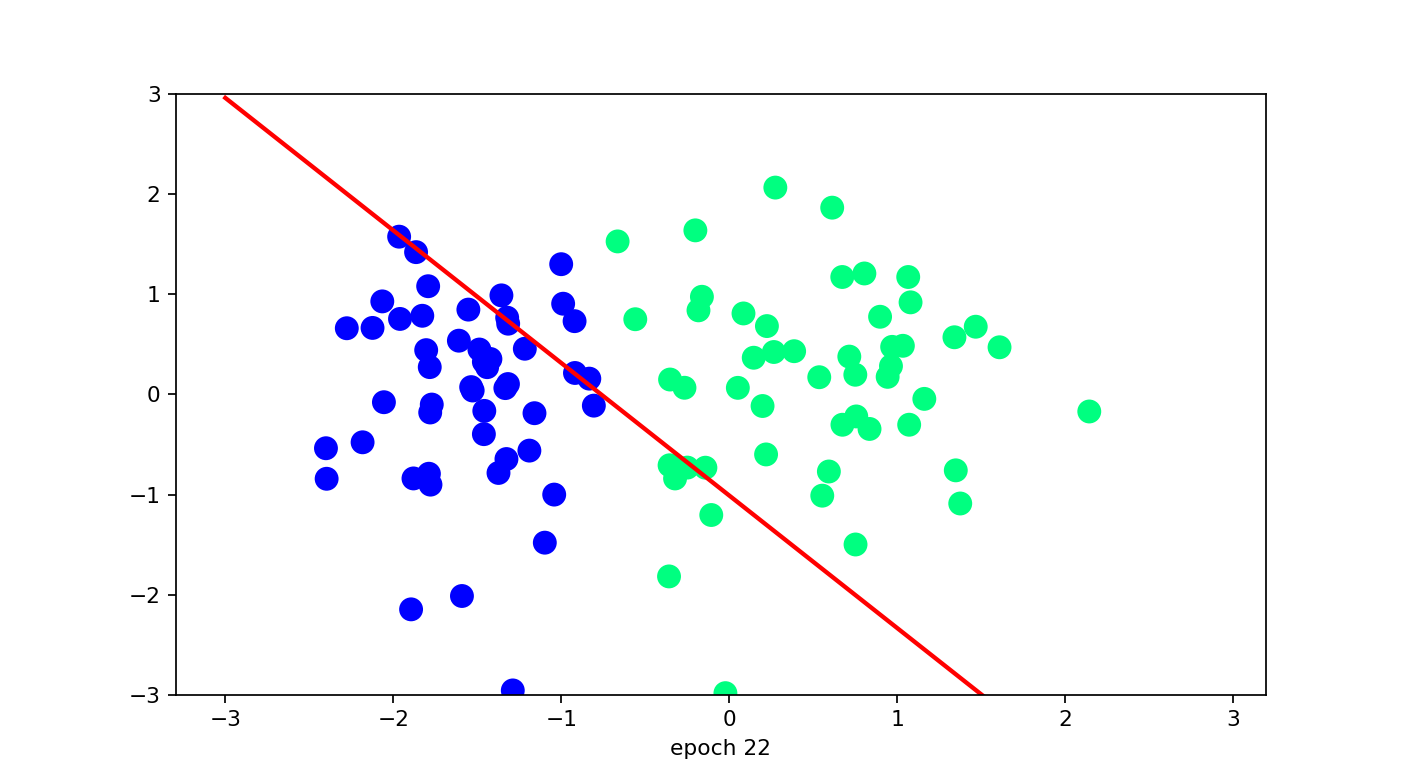

In [60]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)

In [18]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [19]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [20]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

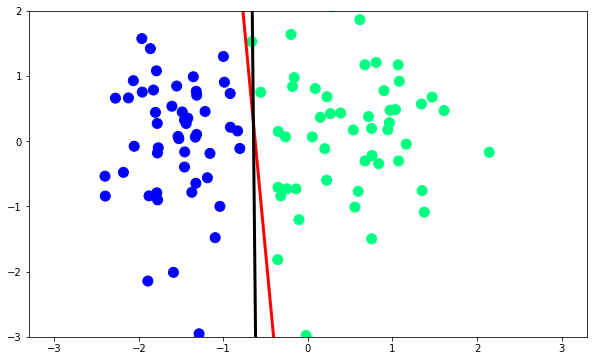

In [21]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)